In [5]:
from keras.models import Model

This notebook demonstrates how to build a Keras model with multiple outputs.

### **Step 1: Import necessary modules**

The first two cells import `Model` from `keras.models` and all layers from `keras.layers`. These are essential for defining and constructing a Keras model.

In [6]:
from keras.layers import *

In [7]:
x = Input(shape=(3,))

### **Step 2: Define the input layer**

This cell defines the input layer `x` for the model. It's a placeholder for input data with a shape of `(3,)`, meaning each input sample will have 3 features.

In [8]:
hidden1 = Dense(128,activation='relu')(x)
hidden2 = Dense(64,activation='relu')(hidden1)

output1 = Dense(1,activation='linear')(hidden2)
output2 = Dense(1,activation='sigmoid')(hidden2)

### **Step 3: Define hidden layers and multiple output layers**

Here, two `Dense` (fully connected) hidden layers are created:
- `hidden1` has 128 neurons and uses the `relu` activation function.
- `hidden2` has 64 neurons and also uses the `relu` activation function.

After the hidden layers, two distinct output layers are defined, both taking `hidden2` as input:
- `output1` is a single neuron with a `linear` activation function, suitable for regression tasks.
- `output2` is also a single neuron but uses a `sigmoid` activation function, typically used for binary classification tasks (outputting probabilities between 0 and 1).

In [9]:
model = Model(inputs=x,outputs=[output1,output2])

### **Step 4: Create the Keras Model**

This cell constructs the Keras `Model` by specifying the input layer `x` and a list of output layers `[output1, output2]`. This creates a model that takes a single input and produces two separate outputs.

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

### **Step 5: Display the model summary**

`model.summary()` prints a concise summary of the model's architecture, including the name and type of each layer, its output shape, and the number of trainable parameters.

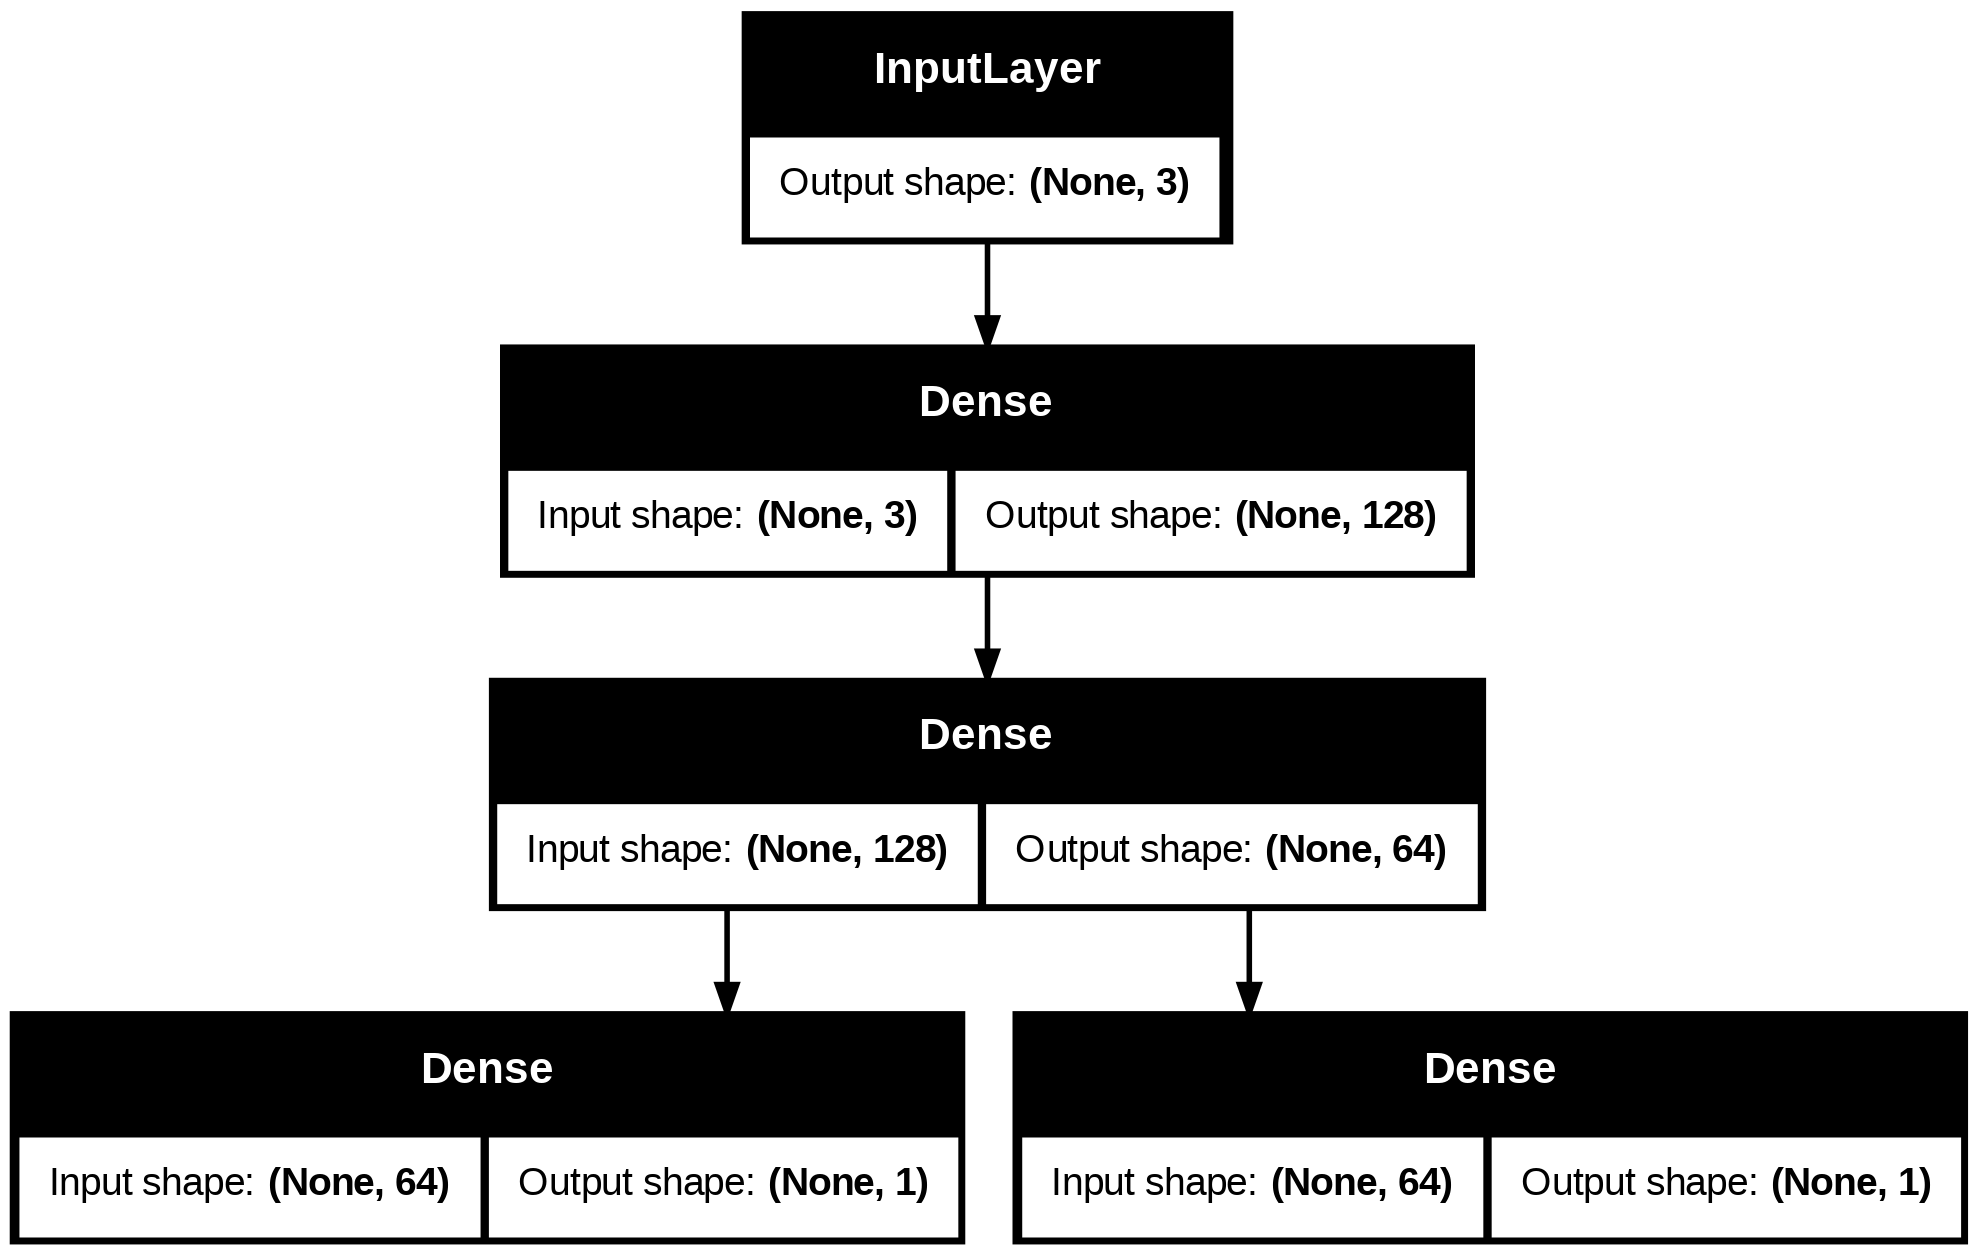

In [11]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)

### **Step 6: Visualize the model architecture**

This cell uses `plot_model` from `keras.utils` to generate a visual graph of the model. `show_shapes=True` ensures that the input and output shapes of each layer are displayed in the plot, providing a clear understanding of the data flow through the network.

### **Step 7: Re-define the model with two input layers**

To have two input layers, you need to define each `Input` separately and then combine them, for example, using a `concatenate` layer, before feeding them into the shared hidden layers.

In [12]:
# Define two input layers
input1 = Input(shape=(3,), name='input_layer_1')
input2 = Input(shape=(5,), name='input_layer_2')

Now, let's process each input branch separately with its own `Dense` layers, then combine them using `concatenate`.

In [13]:
# Process input1
x1 = Dense(64, activation='relu')(input1)
x1 = Dense(32, activation='relu')(x1)

# Process input2
x2 = Dense(128, activation='relu')(input2)
x2 = Dense(64, activation='relu')(x2)

# Concatenate the outputs of the two branches
combined = concatenate([x1, x2])

After combining the inputs, you can feed the `combined` output into your existing hidden and output layers.

In [17]:
# Re-use existing hidden and output layers with the combined input
hidden1_new = Dense(128, activation='relu')(combined)
hidden2_new = Dense(64, activation='relu')(hidden1_new)

# Define a single output layer (e.g., regression output)
single_output = Dense(1, activation='linear', name='single_regression_output')(hidden2_new)

# Create the new model with two inputs and a single output
multi_input_model = Model(inputs=[input1, input2], outputs=single_output)

Now, let's display the summary of this new model with two inputs.

In [18]:
multi_input_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │        768 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      8,256 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ single_regression_… │ (None, 1)         │         65 │ dense_15[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,097 (125.38 KB)

 Trainable params: 32,097 (125.38 KB)

 Non-trainable params: 0 (0.00 B)

And visualize the architecture of the model with two inputs.

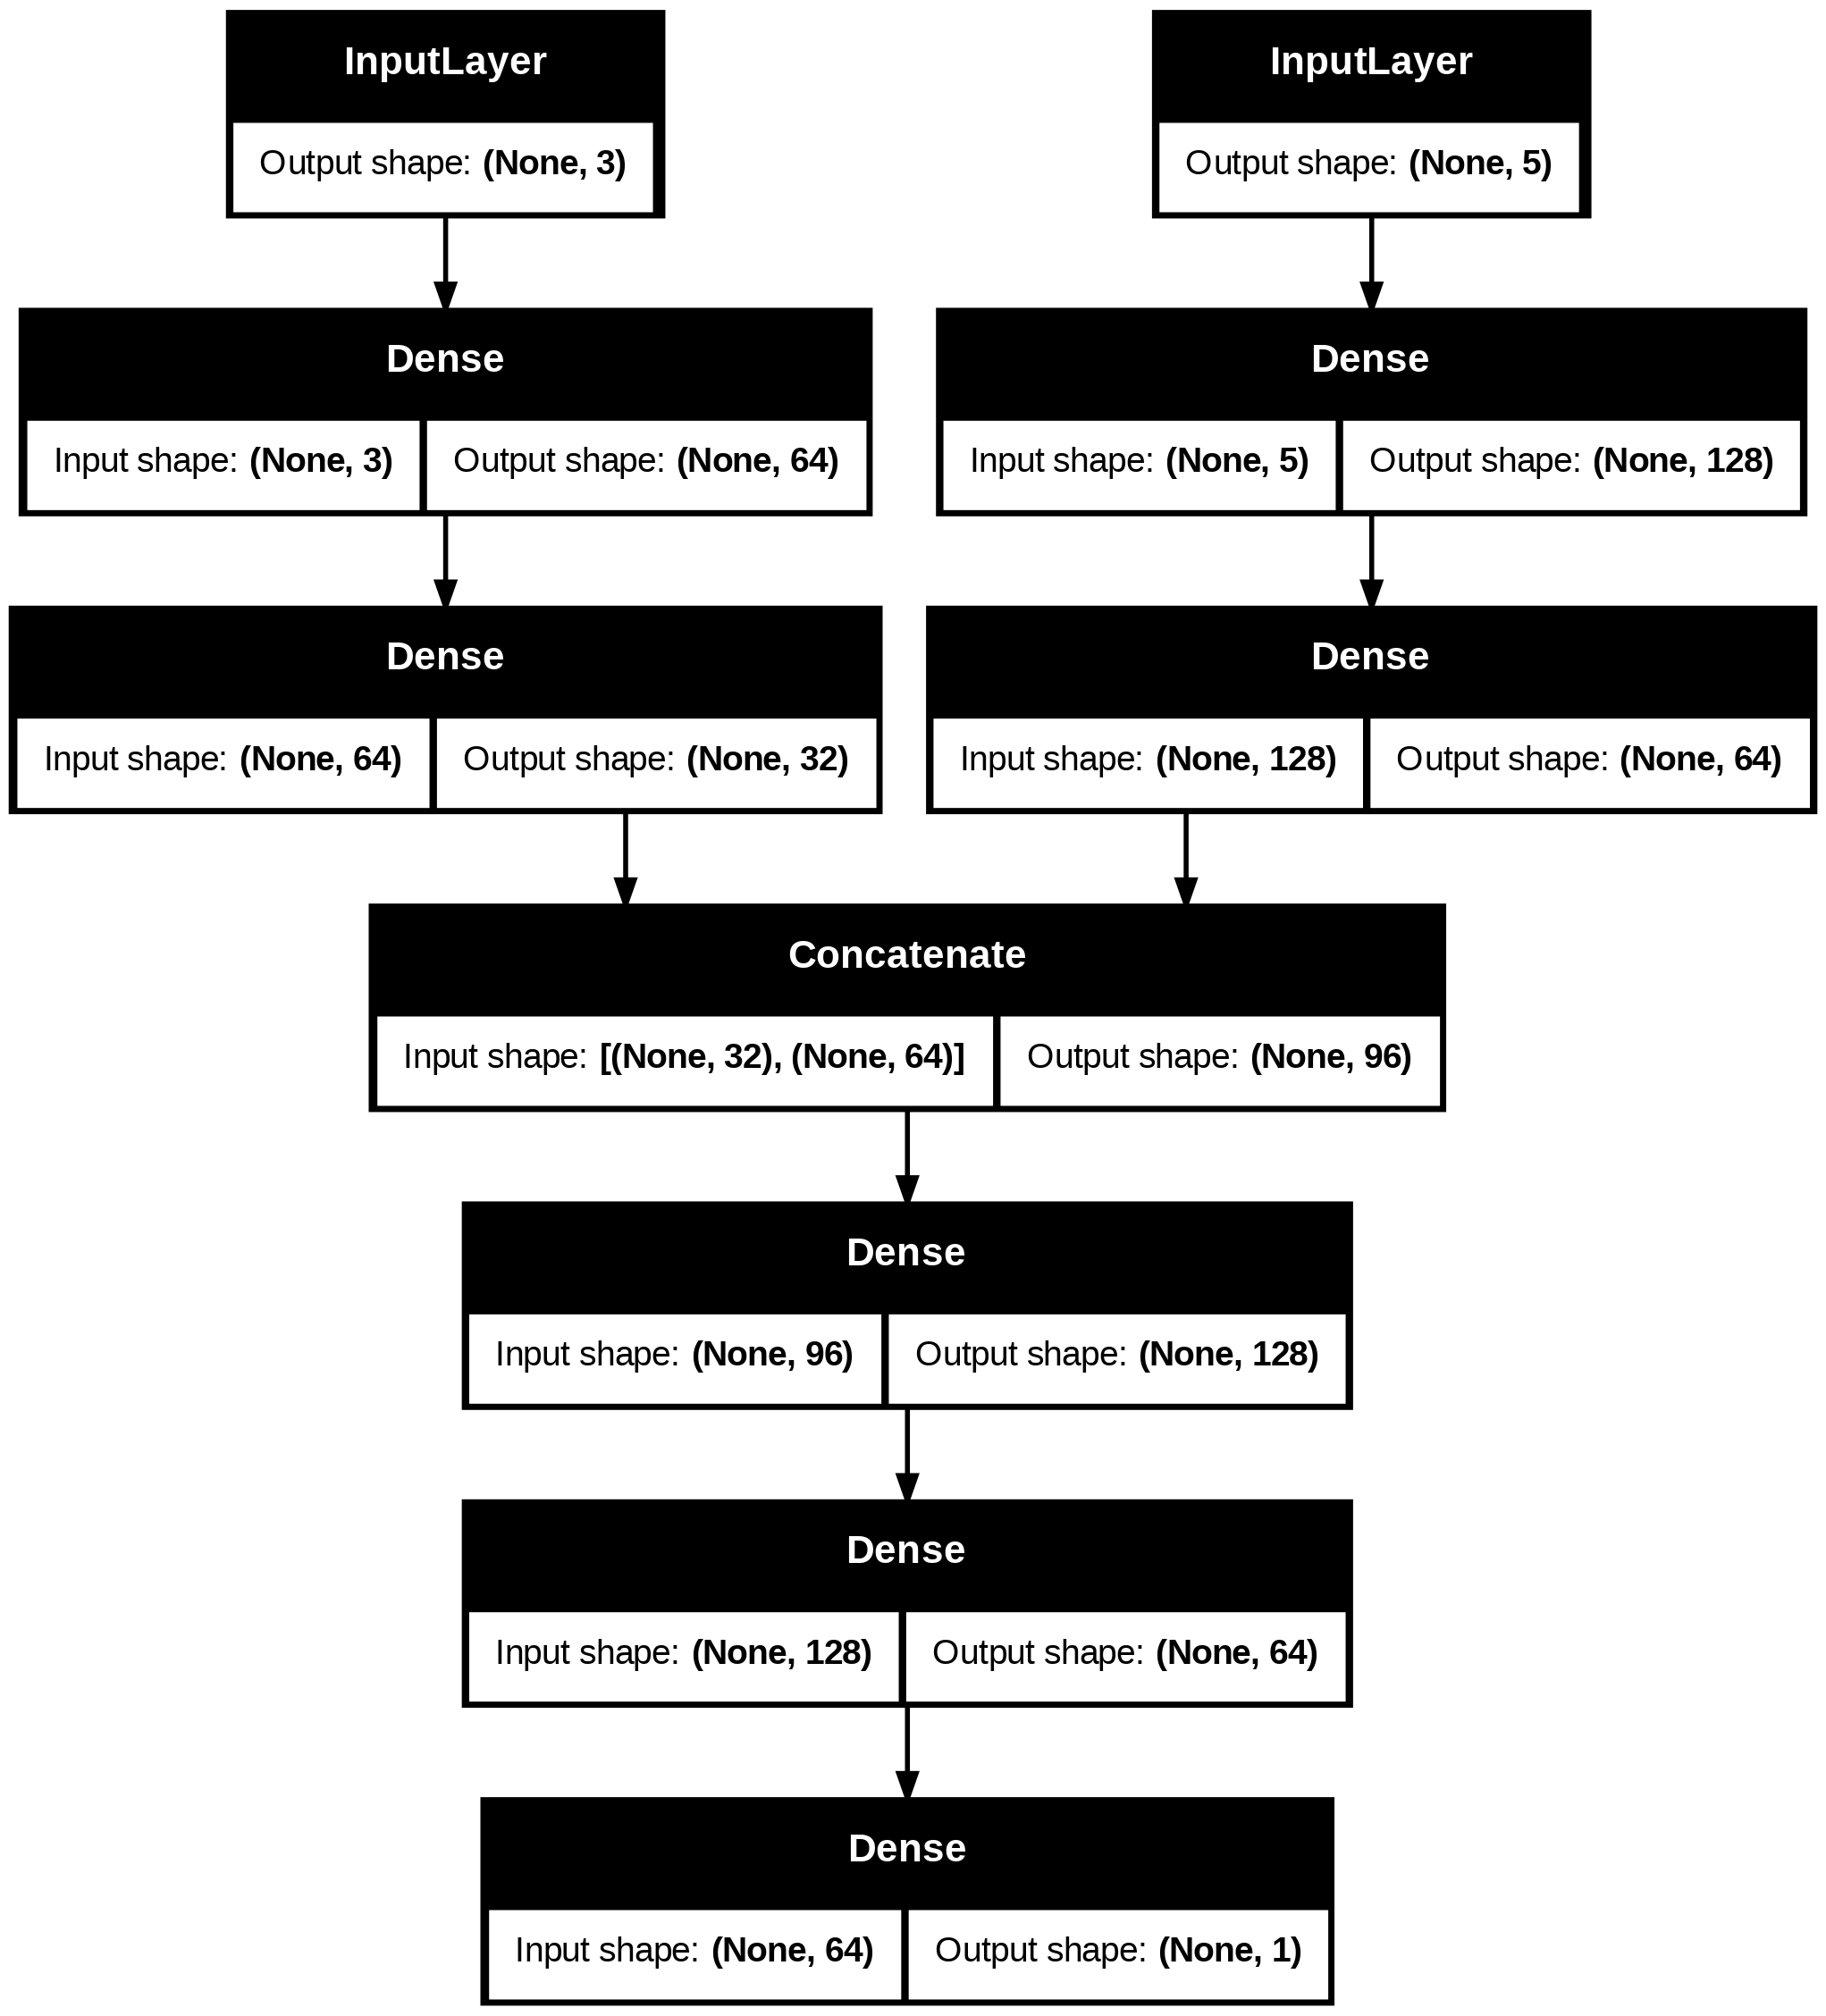

In [19]:
from keras.utils import plot_model
plot_model(multi_input_model, show_shapes=True)